# Load the data

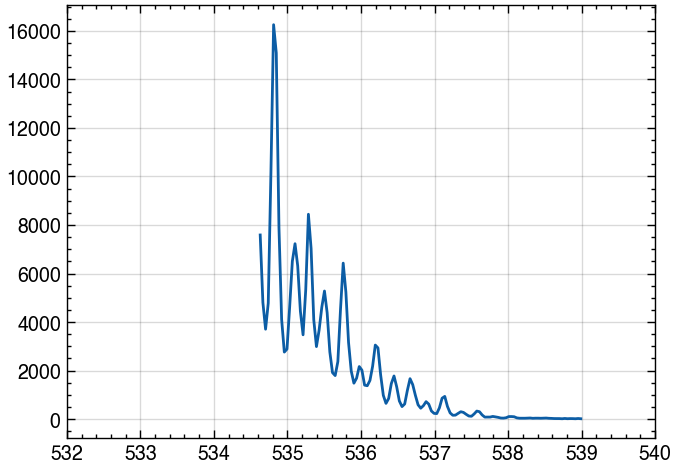

In [18]:
import pickle
import sif_parser
import numpy as np
import matplotlib.pyplot as plt
from toddler.data.spectrum import Spectrum
import wedme
from pathlib import Path
import os

wedme.dev()

f_base = Path(os.path.abspath(""))

s_sig = Spectrum.from_sif(f_base / "spectrum_air_roomtemp_sig.sif").median(axis=2).squeeze()
s_bg = Spectrum.from_sif(f_base / "spectrum_air_roomtemp_bg.sif").median(axis=2).squeeze()
s = (s_sig - s_bg).slice(534.6e-9, 539e-9)

plt.figure()
plt.plot(s.lambdanm, s.sdata, label="Spectrum")
plt.xlim(532, 540)
plt.show()

# Example spectrum

Calculating cross-section
Calculating cross-section


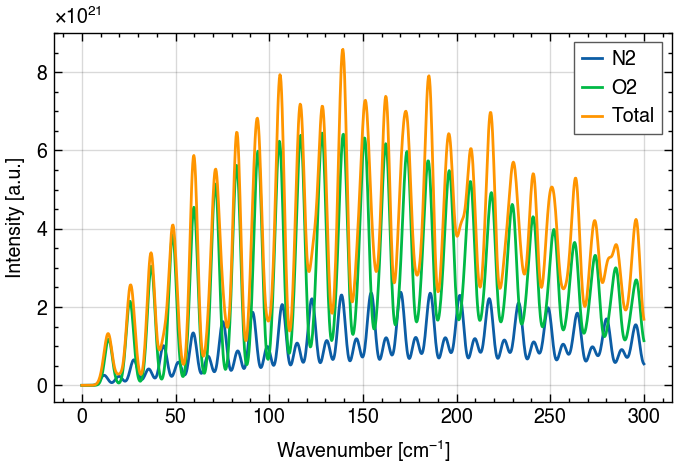

In [12]:
from ramlab.molecules import N2, O2
from ramlab.simulate.raw import RawSimulationMethod, RawBinnedSimulationMethod
from ramlab.simulate.linespreadfunction import Voigt, Hubbert


dnu_sim = np.linspace(0, 300, 1000)
I_tot = np.zeros_like(dnu_sim)

plt.figure()
for m in [N2, O2]:
    transitions = m.get_all_transitions(laser_wavelength=532e-9).filter(dv=0, dJ=2)
    I = m.get_intensity(transitions, T=3000)
    I_sim = RawBinnedSimulationMethod(N_bin=10).simulate(
        dnu_sim, transitions.vacuum_wavenumber, I, Voigt(w_g=2, w_l=0)
    )
    I_tot += I_sim

    plt.plot(dnu_sim, I_sim, label=f"{m.molecule_name}")
plt.plot(dnu_sim, I_tot, label="Total")
plt.legend()
plt.xlabel("Wavenumber [cm$^{-1}$]")
plt.ylabel("Intensity [a.u.]")
plt.show()

# Fit

In [ ]:
from ramlab.molecules import N2, O2
import numpy as np
from ramlab.fit import MultiMoleculeFitRecipe
from ramlab.molecules.polarisation import Polarisation
from ramlab.simulate.linespreadfunction import Voigt, Hubbert
from ramlab.fit.modifiers import WavelengthAxisCorrection, MeasurementSpectrum
from ramlab.simulate.raw import RawSimulationMethod, RawBinnedSimulationMethod

# Put some a-priori guesses for the fit parameters
lineshape=Voigt(w_g = 0.055, w_l = 0.01, vary_g=False, vary_l=False) 
# lineshape=Hubbert(w=0.1, q=1) 
wavelength_correction = WavelengthAxisCorrection(1, initial_values=[-0.3, 0.0147033], vary_wl=False)

fit = MultiMoleculeFitRecipe(
    molecules=[(N2, N2.get_all_transitions(laser_wavelength=532e-9).filter(dv=0, dJ=2)),
               (O2, O2.get_all_transitions(laser_wavelength=532e-9).filter(dv=0, dJ=2)),],
    polarisation=Polarisation.COMBINED,
    lineshape=lineshape,
    meas_modifiers=[
        wavelength_correction,
    ],
    simulation_method=RawBinnedSimulationMethod(N_bin=4),
)

# Fit one of the spectra that has great signal
fit.prepare()
fit.fitparameters['T'].value = 300
fit.fitparameters['T'].vary = False
fit.fitparameters['X_N2'].vary = False
fit.fitparameters['X_N2'].value = 0.8
fit.fitparameters['X_O2'].vary = False
fit.fitparameters['X_O2'].value = 0.2
fit.make(fit.fitparameters, meas=MeasurementSpectrum(s))
print(print(fit.fitparameters))
fitresults = fit.fit(MeasurementSpectrum(s))
# Apply the resulting fit parameters (lineshape, wavelength correction) to the other spectra
# fit.apply_parameters(fitresults.fit_params, 
#                      vary_l=False, vary_g=False, vary_w=False, vary_q=False, # Fix the linewidths
#                      vary_wl=[True, False, False, False] # Fix the wavelength correction of everything other than 0th order
#                      )

# fit.prepare()
# fitresults = fit.fit(MeasurementSpectrum(s))
print(print(fitresults.fit_params))

Calculating cross-section
Calculating cross-section
Parameters([('A', <Parameter 'A', value=1, bounds=[-inf:inf]>), ('T', <Parameter 'T', value=300 (fixed), bounds=[250:10000.0]>), ('X_N2', <Parameter 'X_N2', value=0.8 (fixed), bounds=[0:1]>), ('X_O2', <Parameter 'X_O2', value=0.2 (fixed), bounds=[0:1]>), ('w_g', <Parameter 'w_g', value=0.055 (fixed), bounds=[0:inf]>), ('w_l', <Parameter 'w_l', value=0.01 (fixed), bounds=[0:inf]>), ('lambda_correction_0', <Parameter 'lambda_correction_0', value=-0.3, bounds=[-3:3]>), ('lambda_correction_1', <Parameter 'lambda_correction_1', value=0.0147033, bounds=[-3:3]>)])
None
Parameters([('A', <Parameter 'A', value=np.float64(0.717212663864379) +/- 0.016, bounds=[-inf:inf]>), ('T', <Parameter 'T', value=300 (fixed), bounds=[250:10000.0]>), ('X_N2', <Parameter 'X_N2', value=0.8 (fixed), bounds=[0:1]>), ('X_O2', <Parameter 'X_O2', value=0.2 (fixed), bounds=[0:1]>), ('w_g', <Parameter 'w_g', value=0.055 (fixed), bounds=[0:inf]>), ('w_l', <Parameter 'w

In [35]:
print(fitresults.fit_params['lambda_correction_0'])

<Parameter 'lambda_correction_0', value=np.float64(-0.3488876175047597) +/- 0.0174, bounds=[-3:3]>


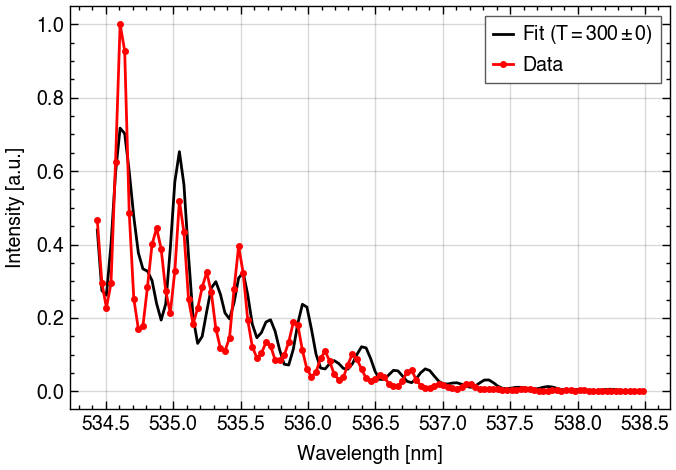

In [36]:
import matplotlib.pyplot as plt
import wedme
from ramlab.display import plot_results

# Plot the fit
wedme.figure.dev()
plot_results(fitresults)
plt.show()

In [36]:
print(fitresults.to_dict().keys())
print(fitresults.fit_params)

dict_keys(['T', 'T_err', 'Ts', 'data_orig', 'data', 'fit', 'residuals', 'fitparameters'])
Parameters([('A', <Parameter 'A', value=np.float64(1.1890334318200602) +/- 0.118, bounds=[-inf:inf]>), ('T', <Parameter 'T', value=300 (fixed), bounds=[250:10000.0]>), ('X_N2', <Parameter 'X_N2', value=0.8 (fixed), bounds=[0:1]>), ('X_O2', <Parameter 'X_O2', value=0.2 (fixed), bounds=[0:1]>), ('w_g', <Parameter 'w_g', value=0.01 (fixed), bounds=[0:inf]>), ('w_l', <Parameter 'w_l', value=0.01 (fixed), bounds=[0:inf]>), ('lambda_correction_0', <Parameter 'lambda_correction_0', value=np.float64(0.04237667997006689) +/- 0.0133, bounds=[-3:3]>), ('lambda_correction_1', <Parameter 'lambda_correction_1', value=np.float64(0.05927914837915793) +/- 0.0158, bounds=[-3:3]>)])
